# BSL Gesture Recognition - Latency Benchmark (Colab)

This notebook measures end-to-end inference latency and throughput across models.

## Models under test
- Deep learning: 1D_CNN, Transformer_Encoder, ADANN
- Machine learning: LightGBM, XGBoost
- Hybrid: ADANN_LightGBM

## Methodology
1. Unified input shape and data type
2. Warmup runs (to stabilize caches/JIT)
3. N measurement runs and report mean latency and throughput
4. Export publication-ready plots (PNG 300 dpi and PDF)
5. Save raw results to CSV


# Section 1: Environment setup & libraries

In [1]:
!pip install torch torchvision torchaudio
!pip install tensorflow
!pip install lightgbm xgboost
!pip install pandas numpy matplotlib seaborn
!pip install psutil
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unins

In [2]:
# Check GPU Environment
import torch
import tensorflow as tf

print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print(f"TensorFlow GPU: {tf.config.list_physical_devices('GPU')}")

# Set random seed
import numpy as np
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

PyTorch CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 39.6 GB
TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Section 2: Mount drive & load model files

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_root = "/content/drive/My Drive/Project"
os.chdir(project_root)

print(f"Working directory: {os.getcwd()}")

# List files for quick check
print("Current directory:", os.getcwd())
print("\nFiles:")
!ls -la

Mounted at /content/drive
Working directory: /content/drive/My Drive/Project
Current directory: /content/drive/My Drive/Project

Files:
total 9996
-rw------- 1 root root  15582 Aug  6 10:44 ADANN_LightGBM_算法详解.md
drwx------ 2 root root   4096 Aug  9 13:24 arduino
-rw------- 1 root root      0 Aug  8 16:11 BSL_延迟测试_Colab.ipynb
-rw------- 1 root root  24125 Aug  9 03:18 colab_latency_benchmark.py
-rw------- 1 root root  38767 Aug  9 04:05 Colab延迟测试代码.md
-rw------- 1 root root   5657 Aug  9 02:40 Colab延迟测试指南.md
-rw------- 1 root root   8146 Aug  6 10:44 compare_models.py
drwx------ 2 root root   4096 Aug  9 13:24 configs
drwx------ 2 root root   4096 Aug  9 13:24 datasets
-rw------- 1 root root  14340 Aug  8 17:42 .DS_Store
drwx------ 2 root root   4096 Aug  9 13:24 .git
-rw------- 1 root root    810 Jul 23 22:37 .gitignore
-rw------- 1 root root 445492 Aug 11 01:09 latency_benchmark_plot_loso_20250811_010901.png
-rw------- 1 root root 449325 Aug 11 02:40 latency_benchmark_plot_loso_20250

# Section 3: Quick model file check


In [4]:
# Quick model file check
model_dirs = [
    # standard
    "models/trained/1D_CNN/standard/full",
    "models/trained/Transformer_Encoder/standard/full",
    "models/trained/LightGBM/standard/full",
    "models/trained/XGBoost/standard/full",
    "models/trained/ADANN/standard/full",
    "models/trained/ADANN_LightGBM/standard/full",
    # loso
    "models/trained/1D_CNN/loso/full",
    "models/trained/Transformer_Encoder/loso/full",
    "models/trained/LightGBM/loso/full",
    "models/trained/XGBoost/loso/full",
    "models/trained/ADANN/loso/full",
    "models/trained/ADANN_LightGBM/loso/full"
]

for dir_path in model_dirs:
    if os.path.exists(dir_path):
        files = os.listdir(dir_path)
        print(f"{dir_path}: {len(files)} files")
    else:
        print(f"{dir_path}: missing")

models/trained/1D_CNN/standard/full: 5 files
models/trained/Transformer_Encoder/standard/full: 5 files
models/trained/LightGBM/standard/full: 4 files
models/trained/XGBoost/standard/full: 4 files
models/trained/ADANN/standard/full: 3 files
models/trained/ADANN_LightGBM/standard/full: 24 files
models/trained/1D_CNN/loso/full: 5 files
models/trained/Transformer_Encoder/loso/full: 5 files
models/trained/LightGBM/loso/full: 4 files
models/trained/XGBoost/loso/full: 4 files
models/trained/ADANN/loso/full: 3 files
models/trained/ADANN_LightGBM/loso/full: 4 files


# Section 4: Latency benchmark class

In [5]:
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
import torch
import gc
import warnings
import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

class ColabLatencyBenchmark:
    def __init__(self):
        self.results = []; self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_warmup = 50; self.num_runs = 1000; self.batch_sizes = [1, 4, 8, 16]
        self.sample_data_dl = np.random.randn(1, 100, 5).astype(np.float32)
        self.sample_data_ml = self.sample_data_dl.reshape(1, -1)
        print(f"Device: {self.device}\nRuns: {self.num_runs}, Warmup: {self.num_warmup}")

    # Find the latest specified extension file in the directory
    def _latest_with_ext(self, dir_path: str, ext: str):
        if not os.path.exists(dir_path):
            return None
        files = sorted([f for f in os.listdir(dir_path) if f.endswith(ext)], reverse=True)
        return os.path.join(dir_path, files[0]) if files else None

    # ---------------------------------
    # 1. Load Mode Method
    # ---------------------------------
    def _load_tflite_model(self, model_path: str, batch_size: int, model_type: str):
        try:
            interpreter = tf.lite.Interpreter(model_path=model_path)
            interpreter.allocate_tensors()
            return interpreter, "tflite"
        except Exception as e:
            print(f"load TFLite fail: {e}"); return None, None

    def _load_ml_model(self, model_path: str, model_type: str):
        try:
            import pickle; import sys
            if '.' not in sys.path: sys.path.insert(0, '.')
            with open(model_path, 'rb') as f:
                if model_type == 'LightGBM': from src.training.train_lightgbm import LightgbmModelCreator
                data = pickle.load(f)
            model = data.get('lgb_model') or data.get('model', data) if isinstance(data, dict) else data
            return model, model_type.lower()
        except Exception as e:
            print(f"load {model_type} file: {e}"); return None, None

    def _load_pytorch_model(self, model_path: str, model_type: str):
        import os, torch
        # Priority is given to directly try to load according to the given path.（Whatever .pth or .keras，it's fine for torch.save）
        try:
            pkg = torch.load(model_path, map_location=self.device, weights_only=False)
            if isinstance(pkg, dict):
                for v in pkg.values():
                    if hasattr(v, 'eval'):
                        v.eval()
            elif hasattr(pkg, 'eval'):
                pkg.eval()
            return pkg, model_type.lower()
        except Exception as e1:
            # If fail, try to load .pth <-> .keras
            alt = None
            if model_path.endswith('.keras'):
                alt = model_path[:-6] + '.pth'
            elif model_path.endswith('.pth'):
                alt = model_path[:-4] + '.keras'
            if alt and os.path.exists(alt):
                try:
                    print(f"ℹ️ Try to load the alternate path {model_type}: {os.path.basename(alt)}")
                    pkg = torch.load(alt, map_location=self.device, weights_only=False)
                    if isinstance(pkg, dict):
                        for v in pkg.values():
                            if hasattr(v, 'eval'):
                                v.eval()
                    elif hasattr(pkg, 'eval'):
                        pkg.eval()
                    return pkg, model_type.lower()
                except Exception as e2:
                    print(f"load {model_type} alternate path fail: {e2}")
            print(f"load {model_type} fail: {e1}")
            return None, None

    # ---------------------------------
    # 2. Inference Method
    # ---------------------------------
    def _inference(self, model, data, framework, model_type):
        try:
            start_time = time.time()
            if framework == 'tflite':
                # If the model is fixed batch=1, the sample cycle method is adopted to avoid dynamic reshape.
                input_details = model.get_input_details()[0]
                output_details = model.get_output_details()[0]
                expected_shape = list(input_details['shape'])
                if len(expected_shape) >= 1 and expected_shape[0] == 1 and data.shape[0] > 1:
                    for i in range(data.shape[0]):
                        model.set_tensor(input_details['index'], data[i:i+1])
                        model.invoke()
                        _ = model.get_tensor(output_details['index'])
                else:
                    model.set_tensor(input_details['index'], data)
                    model.invoke()
            elif framework in ['lightgbm', 'xgboost']:
                if hasattr(model, 'n_features_in_') and data.shape[1] != model.n_features_in_:
                    data = data[:, :model.n_features_in_]
                try:
                    _ = model.predict_proba(data)
                except Exception:
                    _ = model.predict(data)
            else:  # pytorch family: ADANN / ADANN_LightGBM
                if model_type == 'ADANN':
                    # Accept two save keys：'adann_model' or 'model_object'
                    if not isinstance(model, dict):
                        raise ValueError('ADANN Package format error（Not dir）')
                    adann = model.get('adann_model') or model.get('model_object')
                    if adann is None:
                        raise ValueError('ADANN Package lack adann_model / model_object')
                    # Read the top layer first, otherwise get it from the model object properties.
                    extractor = model.get('feature_extractor_obj', getattr(adann, 'feature_extractor_obj', None))
                    scaler = model.get('scaler', getattr(adann, 'scaler', None))
                    if extractor is None or scaler is None:
                        raise ValueError('ADANN package lack scaler or feature_extractor_obj（Top-level or model attributes）')
                    # feature extraction
                    X_features = []
                    for sample in data:
                        X_features.append(extractor.extract_comprehensive_features(sample))
                    X_features = np.array(X_features, dtype=np.float32)
                    X_scaled = scaler.transform(X_features)
                    input_tensor = torch.from_numpy(X_scaled).to(self.device)
                    adann.eval()
                    with torch.no_grad():
                        _ = adann(input_tensor)
                elif model_type == 'ADANN_LightGBM':
                    # Need to include：adann_model, lightgbm_model, adann_scaler, lgb_scaler, hybrid_extractor
                    required_keys = ['adann_model', 'lightgbm_model', 'adann_scaler', 'lgb_scaler', 'hybrid_extractor']
                    if not (isinstance(model, dict) and all(k in model for k in required_keys)):
                        raise ValueError('ADANN_LightGBM包缺少必要对象(adann/lightgbm/scalers/extractor)')
                    adann = model['adann_model']; lgbm = model['lightgbm_model']
                    adann_scaler = model['adann_scaler']; lgb_scaler = model['lgb_scaler']
                    extractor = model['hybrid_extractor']
                    # Feature extraction
                    X_adann, X_lgb = [], []
                    for sample in data:
                        X_adann.append(extractor.enhanced_extractor.extract_comprehensive_features(sample))
                        X_lgb.append(extractor.extract_lightgbm_features(sample))
                    X_adann = np.array(X_adann, dtype=np.float32)
                    X_lgb = np.array(X_lgb, dtype=np.float32)
                    X_adann_scaled = adann_scaler.transform(X_adann)
                    X_lgb_scaled = lgb_scaler.transform(X_lgb)
                    # Forward
                    adann.eval()
                    with torch.no_grad():
                        _ = adann(torch.from_numpy(X_adann_scaled).to(self.device))
                    _ = lgbm.predict_proba(X_lgb_scaled)
                else:
                    raise ValueError(f'Unkonwn PyTorch model type: {model_type}')

            return (time.time() - start_time) * 1000
        except Exception as e:
            print(f"{model_type.upper()} inference loss: {e}"); return -1.0

    # ---------------------------------
    # 3. Core Test Logic
    # ---------------------------------
    def benchmark_model(self, model_type, model_path, training_mode, batch_size):
        print(f"\n[Test] {model_type} ({training_mode}), batch_size={batch_size}")

        # Allow 1D_CNN use dynamic batch（Support by TFLite resize）

        # Load model
        if model_type in ["1D_CNN", "Transformer_Encoder"]:
            model, framework = self._load_tflite_model(model_path, batch_size, model_type)
            sample_data = self.sample_data_dl
        elif model_type in ["LightGBM", "XGBoost"]:
            model, framework = self._load_ml_model(model_path, model_type)
            sample_data = self.sample_data_ml
        else: # PyTorch
            model, framework = self._load_pytorch_model(model_path, model_type)
            # If accidentally get .keras (ADANN package is an error suffix), try torch.load fail, then go back to Keras loading.
            if model is None and model_path.endswith('.keras'):
                try:
                    model = tf.keras.models.load_model(model_path)
                    framework = 'keras'
                except Exception:
                    pass
            sample_data = self.sample_data_dl

        if model is None: print(f"[Skip] model load failed"); return None
        test_data = np.repeat(sample_data, batch_size, axis=0)

        print(f"Warmup {framework}...")
        for _ in range(self.num_warmup):
             if self._inference(model, test_data, framework, model_type) == -1.0:
                 print(f"[Skip] warmup failed"); return None

        latencies = [lat for _ in range(self.num_runs) if (lat := self._inference(model, test_data, framework, model_type)) != -1.0]

        if not latencies: print(f"[Skip] all inference failed"); return None

        result = {'model_name': model_type, 'training_mode': training_mode, 'batch_size': batch_size,
                  'mean_latency_ms': np.mean(latencies), 'std_latency_ms': np.std(latencies),
                  'throughput_inf_per_sec': (1000 * batch_size) / np.mean(latencies)}
        print(f"✅ Mean Inference Latency: {result['mean_latency_ms']:.3f}ms | Throughput: {result['throughput_inf_per_sec']:.2f} inf/sec")
        del model, test_data; gc.collect();
        if self.device.type == 'cuda': torch.cuda.empty_cache()
        return result

    # ---------------------------------
    # 4. Find, run and visualization
    # ---------------------------------
    def find_latest_model(self, model_dir, model_type):
        if not os.path.exists(model_dir):
            return None, None
        if model_type in ["1D_CNN", "Transformer_Encoder"]:
            exts = [".tflite"]
        elif model_type in ["LightGBM", "XGBoost"]:
            exts = [".pkl"]
        else:  # ADANN family (ADANN / ADANN_LightGBM)
            exts = [".pth", ".pt", ".pth.tar", ".keras"]
        files = []
        for f in os.listdir(model_dir):
            if f.startswith('scaler_'):
                continue
            for ext in exts:
                if f.endswith(ext):
                    files.append(f)
                    break
        files = sorted(files, reverse=True)
        if not files:
            # Debug output to help position
            print(f" The dir exists but has not found {model_type} recognizable model file: {model_dir}")
            print(f"   Include files: {sorted(os.listdir(model_dir))[:10]}")
            return None, None
        return os.path.join(model_dir, files[0]), files[0]

    def run_benchmark(self):
        print("Starting BSL inference latency benchmark..."); print("=" * 60)
        models_to_test = [("1D_CNN", "models/trained/1D_CNN/standard/full", "standard"), ("1D_CNN", "models/trained/1D_CNN/loso/full", "loso"), ("Transformer_Encoder", "models/trained/Transformer_Encoder/standard/full", "standard"), ("Transformer_Encoder", "models/trained/Transformer_Encoder/loso/full", "loso"), ("LightGBM", "models/trained/LightGBM/standard/full", "standard"), ("LightGBM", "models/trained/LightGBM/loso/full", "loso"), ("XGBoost", "models/trained/XGBoost/standard/full", "standard"), ("XGBoost", "models/trained/XGBoost/loso/full", "loso"), ("ADANN", "models/trained/ADANN/standard/full", "standard"), ("ADANN", "models/trained/ADANN/loso/full", "loso"), ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/standard/full", "standard"), ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/loso/full", "loso")]
        for model_type, model_dir, training_mode in models_to_test:
            model_path, model_name = self.find_latest_model(model_dir, model_type)
            if not model_path: print(f"[Skip] {model_type} ({training_mode}) model file not found"); continue
            print(f"\n[Model] {model_name} ({training_mode})")
            for batch_size in self.batch_sizes:
                if result := self.benchmark_model(model_type, model_path, training_mode, batch_size): self.results.append(result)
        self.save_and_visualize_results()

    def save_and_visualize_results(self):
        if not self.results: print(" There are no test results to save."); return
        df = pd.DataFrame(self.results); timestamp = time.strftime("%Y%m%d_%H%M%S")
        df.to_csv(f"latency_benchmark_results_{timestamp}.csv", index=False)
        print(f"\nSaved results to: latency_benchmark_results_{timestamp}.csv")
        self.print_summary(df); self.generate_academic_plots(df, timestamp)

    def print_summary(self, df: pd.DataFrame):
        print("\n" + "=" * 60); print("Latency results summary (mean latency in ms)"); print("=" * 60)
        print(df.pivot_table(index=['model_name', 'training_mode'], columns='batch_size', values='mean_latency_ms').to_string(float_format="%.3f"))

    def generate_academic_plots(self, df: pd.DataFrame, timestamp: str):
        print("\nGenerating plots..."); plt.style.use('seaborn-v0_8-whitegrid')
        for mode in ['standard', 'loso']:
            mode_df = df[df['training_mode'] == mode].copy()
            if mode_df.empty: continue
            fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
            fig.suptitle(f'Inference Performance Benchmark ({mode.capitalize()} Training)', fontsize=16, fontweight='bold')
            ax1 = sns.barplot(data=mode_df, x='model_name', y='mean_latency_ms', hue='batch_size', ax=axes[0], palette='viridis')
            ax1.set_title('Mean Inference Latency vs. Batch Size', fontsize=12); ax1.set_ylabel('Mean Latency (ms)'); ax1.set_xlabel('')
            ax1.set_yscale('log')  # log scale for improved readability
            ax1.tick_params(axis='x', rotation=30, labelsize=10)
            for p in ax1.patches:
                ax1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=8, color='black', xytext=(0, 5), textcoords='offset points')
            ax1.legend(title='Batch Size', loc='upper left')
            ax2 = sns.lineplot(data=mode_df, x='batch_size', y='throughput_inf_per_sec', hue='model_name', marker='o', ax=axes[1], palette='tab10')
            ax2.set_title('Throughput vs. Batch Size', fontsize=12); ax2.set_ylabel('Throughput (inferences/sec)'); ax2.set_xlabel('Batch Size')
            ax2.set_xticks(self.batch_sizes); ax2.legend(title='Model', loc='upper left'); ax2.set_yscale('log'); ax2.grid(True, which="both", ls="--")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plot_path_png = f"latency_benchmark_plot_{mode}_{timestamp}.png"; plot_path_pdf = f"latency_benchmark_plot_{mode}_{timestamp}.pdf"
            plt.savefig(plot_path_png, dpi=300); plt.savefig(plot_path_pdf); print(f"Saved plots: {plot_path_png}, {plot_path_pdf}"); plt.show()

# Section 5: Run the benchmark

Device: cuda
Runs: 1000, Warmup: 50
Starting BSL inference latency benchmark...

[Model] 1D_CNN_standard_20250806_144109.tflite (standard)

[Test] 1D_CNN (standard), batch_size=1
Warmup tflite...
✅ Mean Inference Latency: 0.044ms | Throughput: 22546.75 inf/sec

[Test] 1D_CNN (standard), batch_size=4
Warmup tflite...
✅ Mean Inference Latency: 0.139ms | Throughput: 28878.04 inf/sec

[Test] 1D_CNN (standard), batch_size=8
Warmup tflite...
✅ Mean Inference Latency: 0.259ms | Throughput: 30841.07 inf/sec

[Test] 1D_CNN (standard), batch_size=16
Warmup tflite...
✅ Mean Inference Latency: 0.492ms | Throughput: 32518.07 inf/sec

[Model] 1D_CNN_loso_final_20250806_143459.tflite (loso)

[Test] 1D_CNN (loso), batch_size=1
Warmup tflite...
✅ Mean Inference Latency: 0.045ms | Throughput: 22391.71 inf/sec

[Test] 1D_CNN (loso), batch_size=4
Warmup tflite...
✅ Mean Inference Latency: 0.138ms | Throughput: 28922.49 inf/sec

[Test] 1D_CNN (loso), batch_size=8
Warmup tflite...
✅ Mean Inference Latency: 

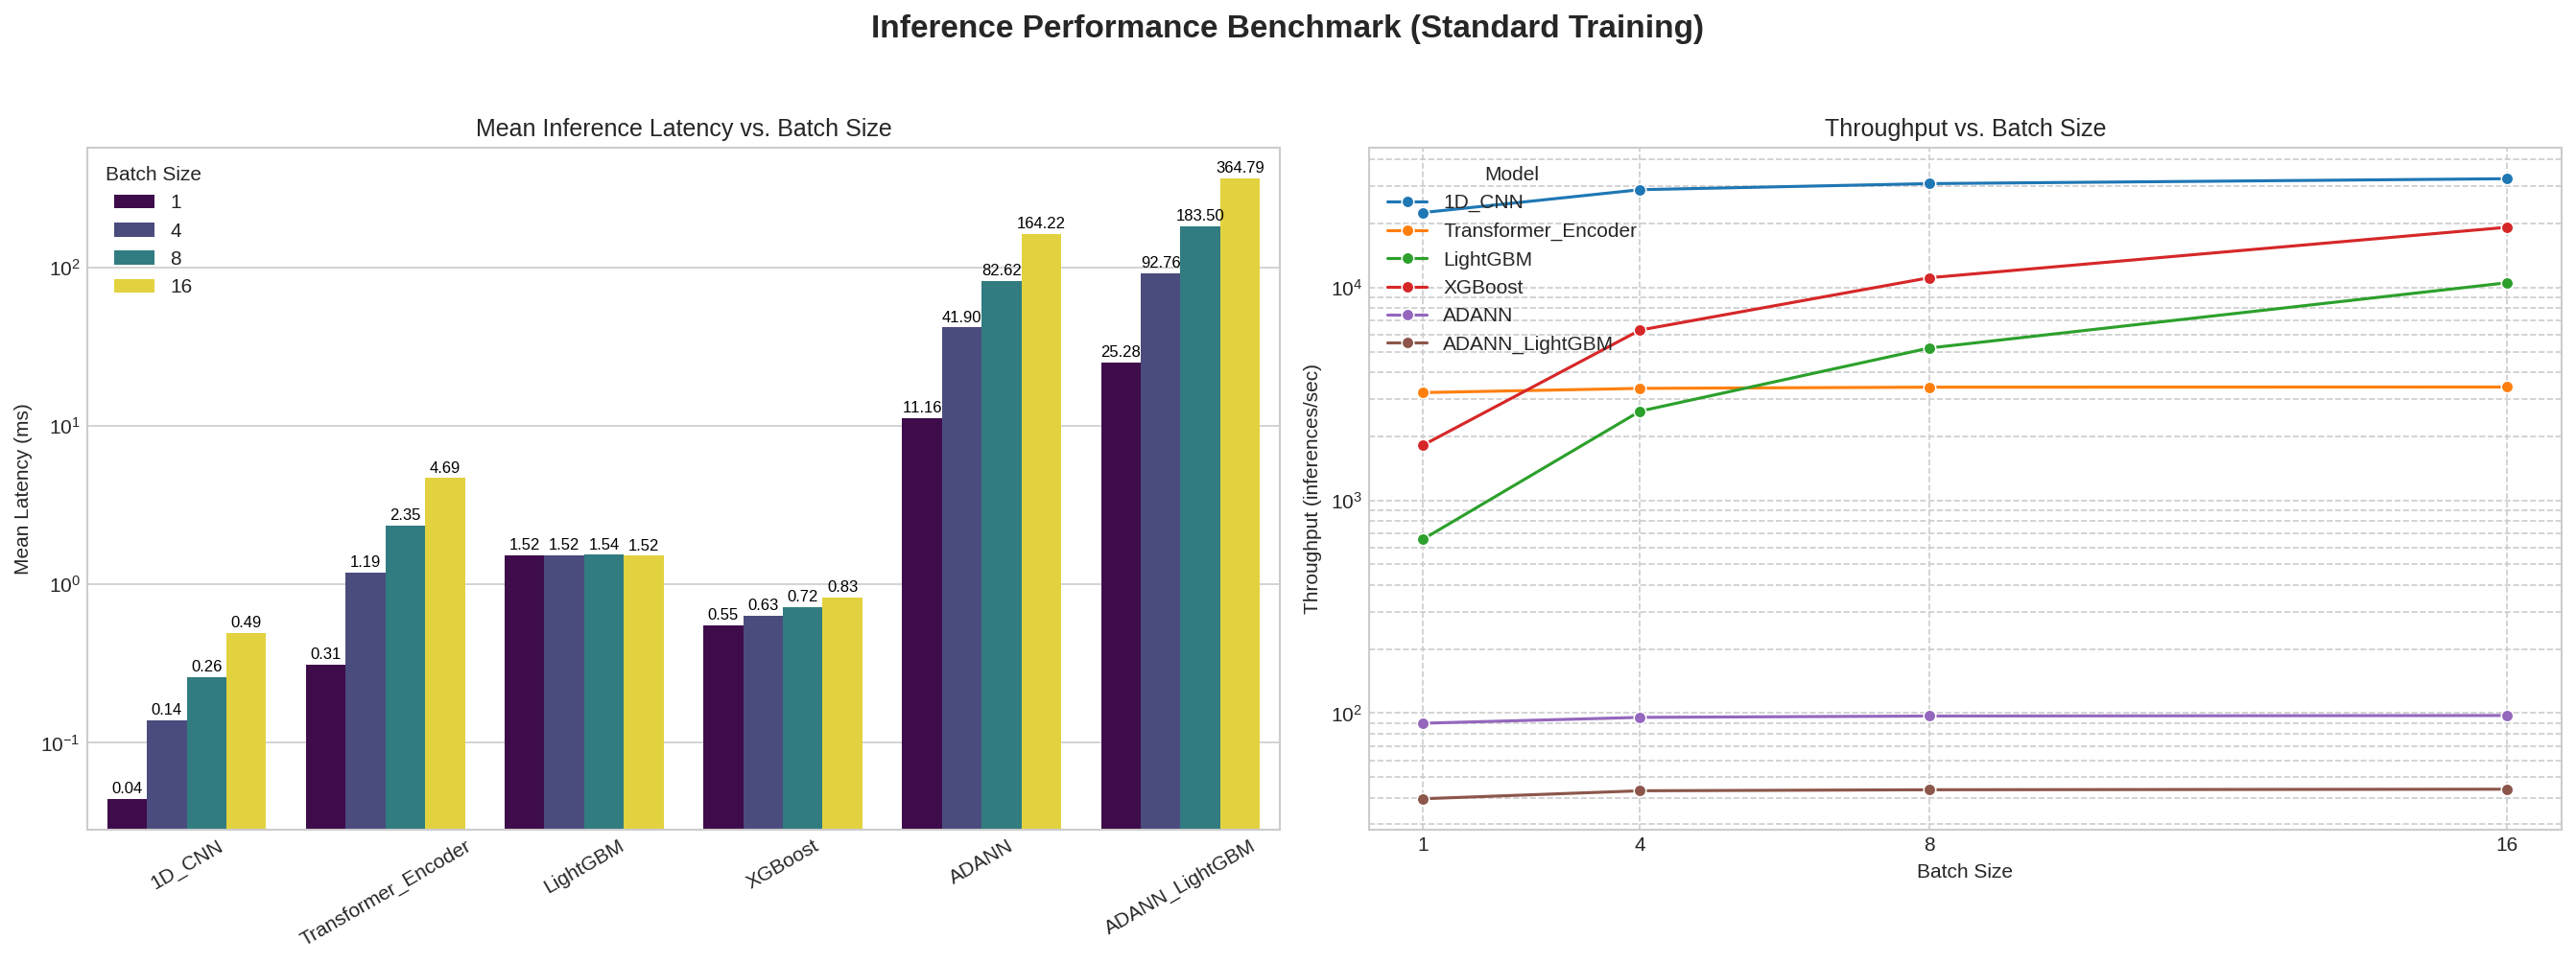

Saved plots: latency_benchmark_plot_loso_20250811_163718.png, latency_benchmark_plot_loso_20250811_163718.pdf


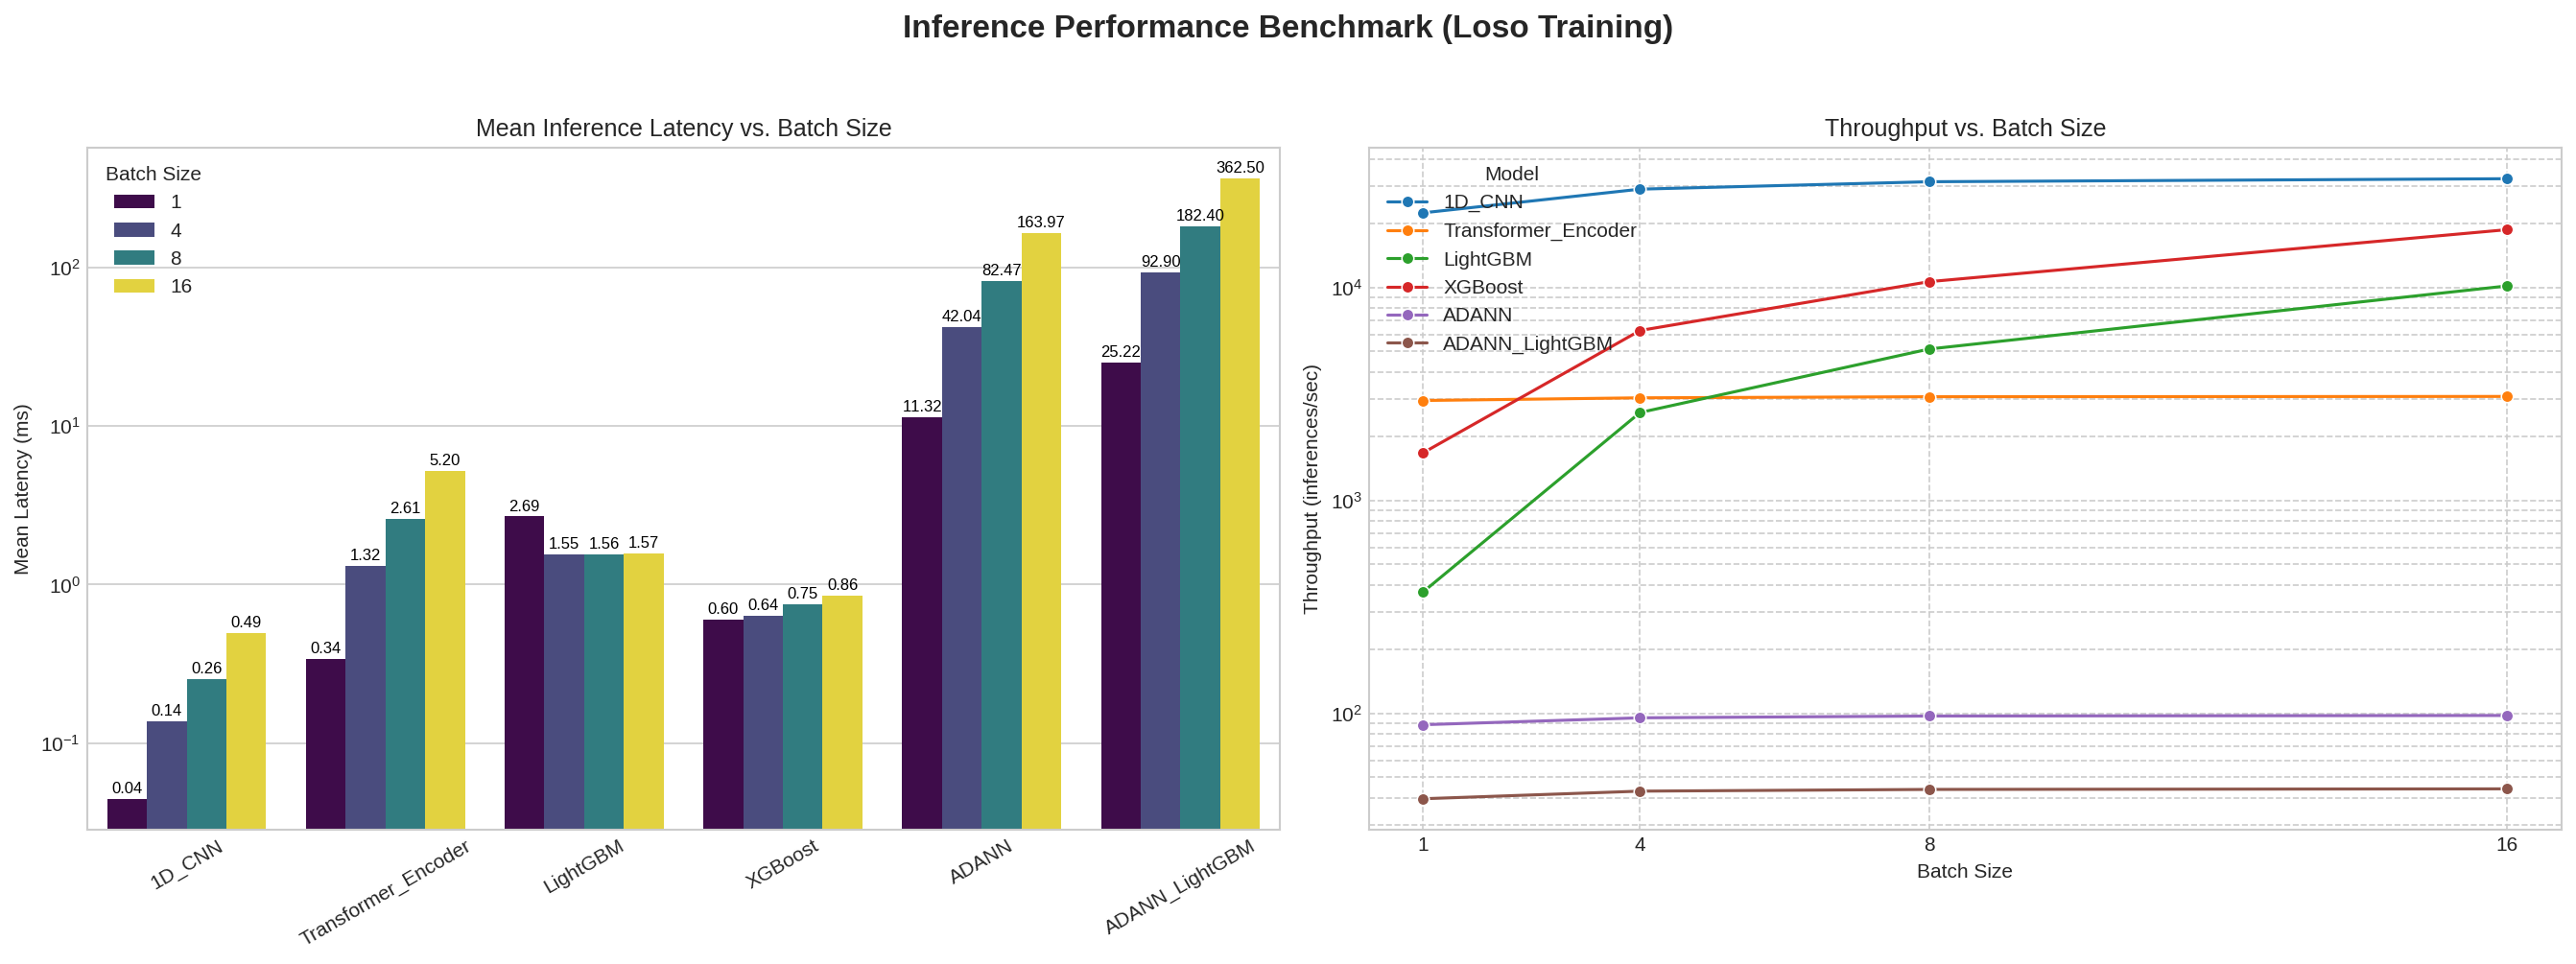

In [6]:
benchmark = ColabLatencyBenchmark()
benchmark.run_benchmark()